## I. Classification binaire : 

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


### 1. Dataset :  

#### a. Create the data 

In [78]:
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1000, 2)
y shape: (1000,)


#### b. Dataset Dimensions

 Input Dimensions: 2 ($X_1$ and $X_2$).

 Output Dimensions: 1 (binary label, 0 or 1).

#### c. Visualize Data

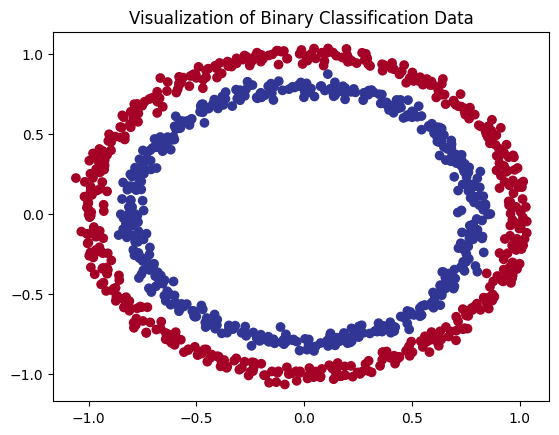

In [79]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Visualization of Binary Classification Data")
plt.show()

#### d. Linearity

This dataset requires a non-linear function because the data points are arranged in two concentric circles

#### e. Train-Test

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train : {len(X_train)}")
print(f"Test : {len(X_test)}")

Train : 800
Test : 200


### 2.2 Définition du modèle 

##### a. Définir le modèle  :  

In [81]:
model = Sequential()
model.add(Dense(100, activation='sigmoid', input_shape=(2,)))
model.add(Dense(1, activation='sigmoid'))

##### b. Summary :  

In [82]:
model.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_107 (Dense)               │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Compilation du modèle

In [83]:
model.compile(loss='binary_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

### 2.4 Entrainement du modèle 

In [84]:
# Train
history = model.fit(X_train, y_train, 
                    epochs=100, 
                    verbose=0, 
                    validation_data=(X_test, y_test))

# Display
for epoch in range(0, 101, 10):
    if epoch == 0: continue
    loss = history.history['loss'][epoch-1]
    acc = history.history['accuracy'][epoch-1]
    val_loss = history.history['val_loss'][epoch-1]
    val_acc = history.history['val_accuracy'][epoch-1]
    print(f"Epoch {epoch}: Loss: {loss:.4f}, Acc: {acc:.4f}, Test Loss: {val_loss:.4f}, Test Acc: {val_acc:.4f}")

Epoch 10: Loss: 0.6937, Acc: 0.5013, Test Loss: 0.6941, Test Acc: 0.5000
Epoch 20: Loss: 0.6939, Acc: 0.5238, Test Loss: 0.6938, Test Acc: 0.4950
Epoch 30: Loss: 0.6940, Acc: 0.5125, Test Loss: 0.6939, Test Acc: 0.5200
Epoch 40: Loss: 0.6944, Acc: 0.4650, Test Loss: 0.6941, Test Acc: 0.5000
Epoch 50: Loss: 0.6941, Acc: 0.4913, Test Loss: 0.6941, Test Acc: 0.4000
Epoch 60: Loss: 0.6935, Acc: 0.5063, Test Loss: 0.6940, Test Acc: 0.4650
Epoch 70: Loss: 0.6945, Acc: 0.4787, Test Loss: 0.6941, Test Acc: 0.4950
Epoch 80: Loss: 0.6944, Acc: 0.4988, Test Loss: 0.6942, Test Acc: 0.4050
Epoch 90: Loss: 0.6943, Acc: 0.4900, Test Loss: 0.6941, Test Acc: 0.4550
Epoch 100: Loss: 0.6941, Acc: 0.5225, Test Loss: 0.6941, Test Acc: 0.4550


### 2.5 Evaluation du modèle

##### a. Boundry  :  

Train Boundary:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step


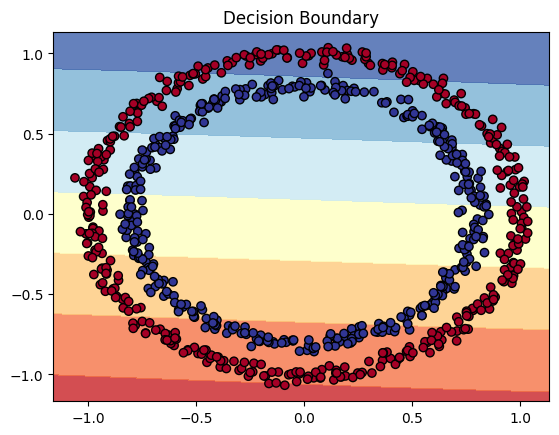

Test Boundary:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step


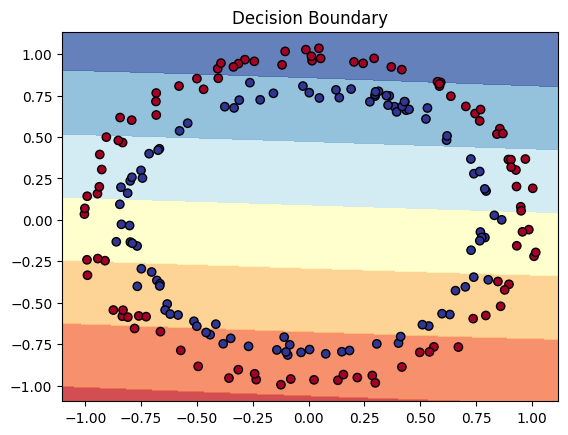

In [85]:
def plot_decision_boundary(model, X, y):

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Predict
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # contour
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()


print("Train Boundary:")
plot_decision_boundary(model, X_train, y_train)

print("Test Boundary:")
plot_decision_boundary(model, X_test, y_test)

##### b. Probleme  : 

- incapacité a capturer la non linearité 


##### b. Ameliorations  : 

- remplacer sigmoid par ReLU ( avoid vanishing gradient )

- sgd ==> Adam ( more efficient for non-linearity )

- maybe : Add More Layers/Complexity

In [86]:

model_v2 = Sequential([
    Dense(100, activation='relu', input_shape=(2,)),
    # Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_v2.compile(loss='binary_crossentropy',
                 optimizer='adam',                
                 metrics=['accuracy'])



Epoch 10: Loss: 0.6653, Acc: 0.6538, Test Loss: 0.6701, Test Acc: 0.5800
Epoch 20: Loss: 0.6193, Acc: 0.9625, Test Loss: 0.6310, Test Acc: 0.8900
Epoch 30: Loss: 0.5598, Acc: 0.9688, Test Loss: 0.5798, Test Acc: 0.9800
Epoch 40: Loss: 0.4892, Acc: 0.9937, Test Loss: 0.5163, Test Acc: 0.9700
Epoch 50: Loss: 0.4160, Acc: 0.9975, Test Loss: 0.4505, Test Acc: 0.9750
Epoch 60: Loss: 0.3501, Acc: 0.9975, Test Loss: 0.3896, Test Acc: 1.0000
Epoch 70: Loss: 0.2935, Acc: 1.0000, Test Loss: 0.3349, Test Acc: 1.0000
Epoch 80: Loss: 0.2424, Acc: 1.0000, Test Loss: 0.2842, Test Acc: 1.0000
Epoch 90: Loss: 0.2016, Acc: 1.0000, Test Loss: 0.2434, Test Acc: 1.0000
Epoch 100: Loss: 0.1696, Acc: 1.0000, Test Loss: 0.2097, Test Acc: 1.0000
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step


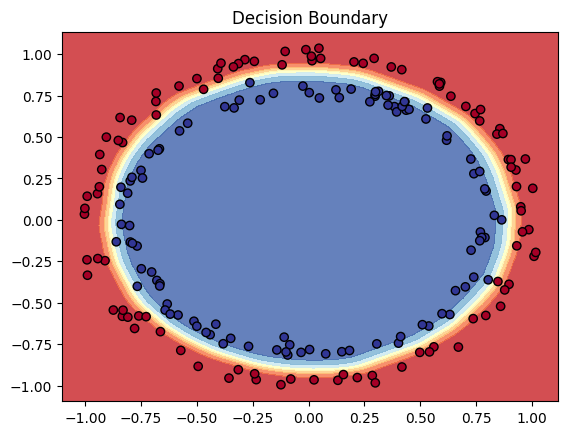

In [87]:
history = model_v2.fit(X_train, y_train, 
                    epochs=100, 
                    verbose=0,
                    validation_data=(X_test, y_test))

model_v2.fit(X_train, y_train, epochs=100, verbose=0)

# progress
for epoch in range(0, 101, 10):
    if epoch == 0: continue
    loss = history.history['loss'][epoch-1]
    acc = history.history['accuracy'][epoch-1]
    val_loss = history.history['val_loss'][epoch-1]
    val_acc = history.history['val_accuracy'][epoch-1]
    print(f"Epoch {epoch}: Loss: {loss:.4f}, Acc: {acc:.4f}, Test Loss: {val_loss:.4f}, Test Acc: {val_acc:.4f}")

# boundary
plot_decision_boundary(model_v2, X_test, y_test)

## II. Multi-Classification : 

### 1.2.3 Data

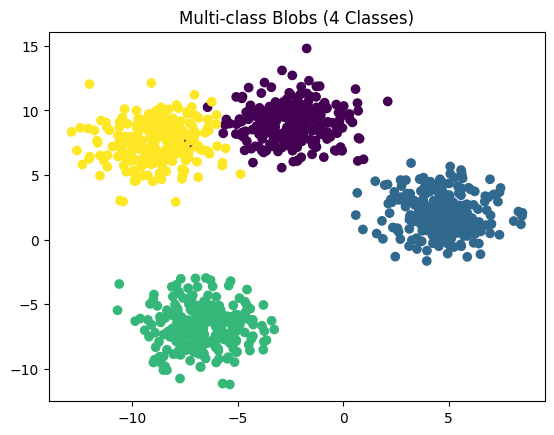

In [88]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# create 
X_multi, y_multi = make_blobs(n_samples=1000, 
                             n_features=2, 
                             centers=4, 
                             cluster_std=1.5, 
                             random_state=42)

#  Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, 
                                                            test_size=0.2, 
                                                            random_state=42)

# Visualize
plt.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap='viridis')
plt.title("Multi-class Blobs (4 Classes)")
plt.show()

### 4. Linearity


This dataset requires a non-linear approach.

a single linear model cannot partition the plane into four distinct regions for four classes simultaneously

#### 5. Model Architecture

In [89]:

multi_model = Sequential([
    Dense(10, activation='relu', input_shape=(2,)),
    Dense(10, activation='relu'),
    Dense(4, activation='softmax') 
])

multi_model.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

#### 6. Training

In [90]:
history = multi_model.fit(X_train_m, y_train_m, 
                          epochs=100, 
                          validation_data=(X_test_m, y_test_m), 
                          verbose=0)

# progress
for i in range(9, 100, 10):
    print(f"Epoch {i+1}: Loss: {history.history['loss'][i]:.4f}, "
          f"Acc: {history.history['accuracy'][i]:.4f}, "
          f"Test Acc: {history.history['val_accuracy'][i]:.4f}")

Epoch 10: Loss: 0.0920, Acc: 0.9912, Test Acc: 0.9950
Epoch 20: Loss: 0.0401, Acc: 0.9925, Test Acc: 0.9950
Epoch 30: Loss: 0.0311, Acc: 0.9912, Test Acc: 0.9950
Epoch 40: Loss: 0.0274, Acc: 0.9912, Test Acc: 0.9950
Epoch 50: Loss: 0.0258, Acc: 0.9925, Test Acc: 0.9950
Epoch 60: Loss: 0.0250, Acc: 0.9912, Test Acc: 0.9950
Epoch 70: Loss: 0.0238, Acc: 0.9937, Test Acc: 0.9950
Epoch 80: Loss: 0.0229, Acc: 0.9925, Test Acc: 0.9950
Epoch 90: Loss: 0.0218, Acc: 0.9937, Test Acc: 0.9950
Epoch 100: Loss: 0.0214, Acc: 0.9937, Test Acc: 0.9950


#### 7. Metrics

In [91]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(multi_model.predict(X_test_m), axis=1)
print(classification_report(y_test_m, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_m, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        49
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        53
           3       1.00      0.98      0.99        57

    accuracy                           0.99       200
   macro avg       0.99      1.00      1.00       200
weighted avg       1.00      0.99      1.00       200

Confusion Matrix:
 [[49  0  0  0]
 [ 0 41  0  0]
 [ 0  0 53  0]
 [ 1  0  0 56]]


#### 8. Boundries


 
 Training  Boundary:
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step


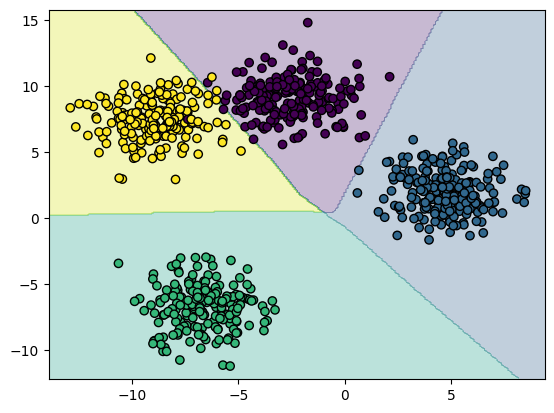


 
 Test Boundary:
1629/1629 ━━━━━━━━━━━━━━━━━━━━ 1s 683us/step


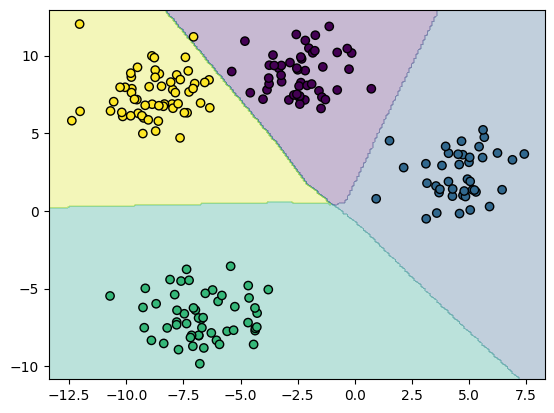

In [92]:
def plot_boundaries(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
                         np.arange(y_min, y_max, 0.1))
    Z = np.argmax(model.predict(np.c_[xx.ravel(), yy.ravel()]), axis=1)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.show()


print("\n \n Training  Boundary:")
plot_boundaries(multi_model, X_train_m, y_train_m)

print("\n \n Test Boundary:")
plot_boundaries(multi_model, X_test_m, y_test_m)


#### 9. effet nombre echantillons

c:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


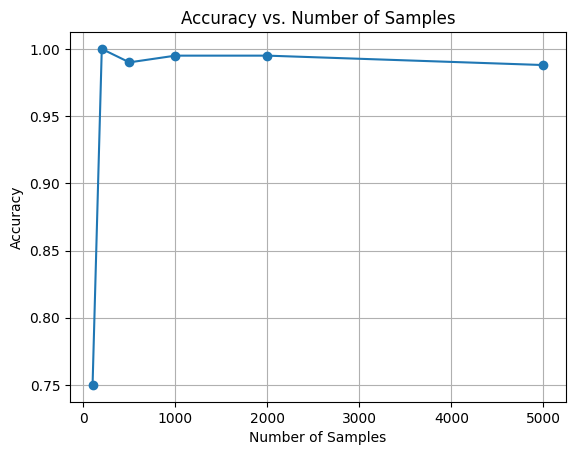

In [93]:

sample_sizes = [100, 200, 500, 1000, 2000, 5000]
accuracies = []

for n in sample_sizes:
    # data
    X_n, y_n = make_blobs(n_samples=n, n_features=2, centers=4, cluster_std=1.5, random_state=42)
    
    # Split
    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_n, y_n, test_size=0.2, random_state=42)
    
    # model
    model_n = Sequential([
        Dense(10, activation='relu', input_shape=(2,)),
        Dense(10, activation='relu'),
        Dense(4, activation='softmax')
    ])
    model_n.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # Train
    model_n.fit(X_train_n, y_train_n, epochs=50, verbose=0)
    
    # Evaluate
    loss, acc = model_n.evaluate(X_test_n, y_test_n, verbose=0)
    accuracies.append(acc)

# Plot
plt.plot(sample_sizes, accuracies, marker='o')
plt.title("Accuracy vs. Number of Samples")
plt.xlabel("Number of Samples")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()